# ABM seeding test — Fibroblast self-clustering via simulated annealing

Pipeline being prototyped here:

1. **Sample density.** Read `density_histogram_bins.csv` and pull the median Fibroblast density (cells/mm²) from the empirical CDF.
2. **Initialize.** Place that many Fib agents at uniformly random positions on a 1 mm × 1 mm grid.
3. **Anneal.** Run simulated annealing on agent positions to minimize the distance between the simulated Fib→Fib FunCN histogram and the measured one in `funcn_histogram_bins.csv`.

## Note on the simple version

The measured FunCN is NW-normalized — its denominator at each Fib cell is the *total* kernel-weighted neighborhood across **all** cell types. If we simulate only Fibs the denominator collapses to the numerator and self-FunCN is identically 1, so there is nothing to anneal against. To get a meaningful single-type test, this notebook adds an **analytical, uniform background** of non-Fib cells at the V2 cohort difference (≈ total cells/mm² − Fib cells/mm²) directly into the FunCN denominator. No background agents are simulated; only Fib positions move. The full multi-type version would replace this constant with the per-cell kernel-weighted density of explicitly-placed background agents.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("out")
rng = np.random.default_rng(0)

# Geometry / kernel / cohort constants
GRID_UM      = 1000.0   # 1 mm side
SIGMA_UM     = 20.0     # FunCN Gaussian sigma (matches funcn_v2)
TOTAL_DENS   = 6289.0   # cells/mm² — V2 cohort: 1,993,303 cells / 317.09 mm²
N_BINS_FUNCN = 40       # must match funcn_histogram_bins.csv
BIN_EDGES_FUNCN = np.linspace(0.0, 1.0, N_BINS_FUNCN + 1)

## 1. Load histogram CSVs

In [2]:
density_df = pd.read_csv(OUT_DIR / "density_histogram_bins.csv")
funcn_df   = pd.read_csv(OUT_DIR / "funcn_histogram_bins.csv")
print(f"density rows: {len(density_df)}  unique types: {density_df['cell_type'].unique().tolist()}")
print(f"funcn rows:   {len(funcn_df)}    unique targets: {funcn_df['target'].unique().tolist()}")

density rows: 150  unique types: ['Endothelial', 'Fibroblast', 'Macrophage', 'CD8 T', 'CD4 T']
funcn rows:   1000    unique targets: ['Endothelial', 'Fibroblast', 'Macrophage', 'CD8 T', 'CD4 T']


## 2. Sample median Fibroblast density

Reconstruct the empirical CDF from bin counts and interpolate the median. For a 1 mm² grid, the agent count equals the density (cells/mm²).

In [3]:
fib_dens = density_df[density_df["cell_type"] == "Fibroblast"].sort_values("bin_index")
centers  = fib_dens["bin_center"].to_numpy()
counts   = fib_dens["count"].to_numpy()
cdf      = np.cumsum(counts) / counts.sum()
median_dens = float(np.interp(0.5, cdf, centers))
N_FIB = int(round(median_dens))   # agents on a 1 mm² grid
rho_other = TOTAL_DENS - median_dens   # cells/mm² assigned to background
print(f"Median Fib density (from histogram CDF): {median_dens:.1f} cells/mm²")
print(f"Agent count on 1 mm² grid: N_FIB = {N_FIB}")
print(f"Background non-Fib density (analytical): {rho_other:.1f} cells/mm²")

Median Fib density (from histogram CDF): 491.4 cells/mm²
Agent count on 1 mm² grid: N_FIB = 491
Background non-Fib density (analytical): 5797.6 cells/mm²


## 3. Initialize positions — uniform on the 1 mm × 1 mm grid

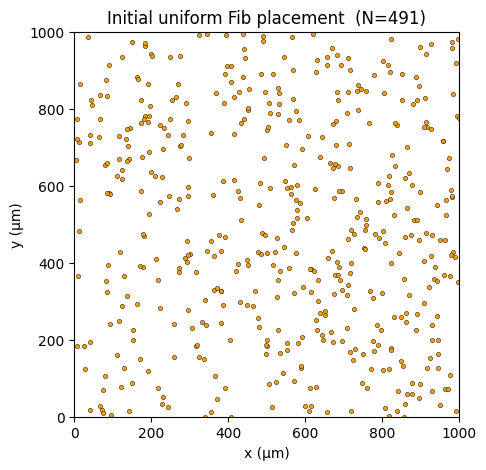

In [4]:
positions_init = rng.uniform(0.0, GRID_UM, size=(N_FIB, 2))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(positions_init[:, 0], positions_init[:, 1], s=10, color="#f39c12", edgecolor="black", linewidth=0.3)
ax.set_xlim(0, GRID_UM); ax.set_ylim(0, GRID_UM)
ax.set_aspect("equal")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"Initial uniform Fib placement  (N={N_FIB})")
plt.show()

## 4. Target FunCN histogram

Pull the (target=Fibroblast, source=Fibroblast) row from the FunCN histogram CSV and convert to a PDF for matching.

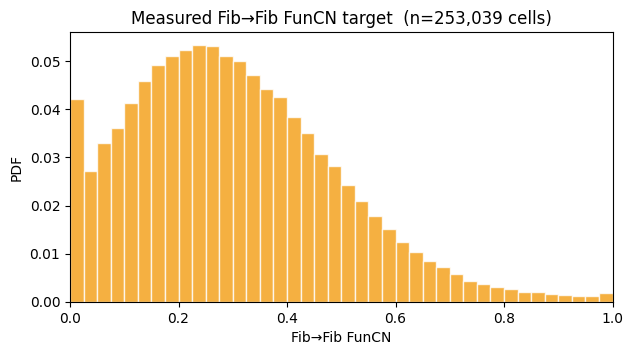

In [5]:
row = funcn_df[(funcn_df["target"] == "Fibroblast") & (funcn_df["source"] == "Fibroblast")].sort_values("bin_index")
target_counts = row["count"].to_numpy()
target_pdf    = target_counts / target_counts.sum()
bin_centers   = row["bin_center"].to_numpy()

# Sanity: bin edges in CSV match the ones we'll re-bin with
assert np.allclose(BIN_EDGES_FUNCN[:-1], row["bin_left"].to_numpy())
assert np.allclose(BIN_EDGES_FUNCN[1:],  row["bin_right"].to_numpy())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(bin_centers, target_pdf, width=1/N_BINS_FUNCN, color="#f39c12", alpha=0.8, edgecolor="white")
ax.set_xlim(0, 1)
ax.set_xlabel("Fib→Fib FunCN"); ax.set_ylabel("PDF")
ax.set_title(f"Measured Fib→Fib FunCN target  (n={target_counts.sum():,} cells)")
plt.show()

## 5. Simulation FunCN and energy

Per-cell FunCN with analytical 2D Gaussian kernel and constant background:

$$\text{FunCN}_i = \frac{\sum_{j\ne i} K_\sigma(d_{ij})}{\sum_{j\ne i} K_\sigma(d_{ij}) + \rho_\text{other}}$$

with $K_\sigma(d) = \frac{1}{2\pi\sigma^2}e^{-d^2/2\sigma^2}$. The kernel is normalized to integrate to 1 over µm², so $\rho_\text{other}$ enters in cells/µm² (i.e. cells/mm² ÷ 10⁶).

Energy is the L1 distance between simulated PDF and target PDF (i.e. histogram total-variation distance).

In [6]:
RHO_OTHER_PER_UM2 = rho_other / 1e6   # cells/µm²
INV_2SIGMA2 = 1.0 / (2.0 * SIGMA_UM ** 2)
K_NORM      = 1.0 / (2.0 * np.pi * SIGMA_UM ** 2)

def pairwise_kernel(positions: np.ndarray) -> np.ndarray:
    """NxN kernel matrix with zero diagonal (leave-one-out)."""
    diff = positions[:, None, :] - positions[None, :, :]
    d2   = (diff * diff).sum(axis=-1)
    K    = K_NORM * np.exp(-d2 * INV_2SIGMA2)
    np.fill_diagonal(K, 0.0)
    return K

def funcn_per_cell(K_sum_per_cell: np.ndarray) -> np.ndarray:
    return K_sum_per_cell / (K_sum_per_cell + RHO_OTHER_PER_UM2)

def histogram_pdf(values: np.ndarray) -> np.ndarray:
    counts, _ = np.histogram(values, bins=BIN_EDGES_FUNCN)
    s = counts.sum()
    return counts / s if s > 0 else counts.astype(float)

def energy_from_pdf(sim_pdf: np.ndarray) -> float:
    return float(np.abs(sim_pdf - target_pdf).sum())

## 6. Initial state — sanity check

For a uniformly random Fib field, kernel-weighted Fib density at each cell concentrates around the bulk mean (≈ N_FIB / area = ρ_Fib), so all cells should have FunCN ≈ ρ_Fib / (ρ_Fib + ρ_other) — a tight peak well below the measured spread.

In [7]:
K = pairwise_kernel(positions_init)
Ksum_init = K.sum(axis=1)
funcn_init = funcn_per_cell(Ksum_init)
sim_pdf_init = histogram_pdf(funcn_init)
E_init = energy_from_pdf(sim_pdf_init)

expected_uniform = (median_dens / 1e6) / (median_dens / 1e6 + RHO_OTHER_PER_UM2)
print(f"Initial energy (L1):           {E_init:.4f}")
print(f"Initial FunCN mean:            {funcn_init.mean():.4f}")
print(f"Bulk-mean prediction (uniform): {expected_uniform:.4f}")
print(f"Target measured mean:           {(target_pdf * bin_centers).sum():.4f}")

Initial energy (L1):           1.4430
Initial FunCN mean:            0.0763
Bulk-mean prediction (uniform): 0.0781
Target measured mean:           0.3035


## 7. Simulated annealing

Single-agent moves with Gaussian step size, geometric cooling. Each move only re-evaluates the affected row/column of the kernel matrix (O(N) per step) — no need to recompute the whole NxN.

In [8]:
def kernel_row(positions: np.ndarray, i: int, new_xy: np.ndarray) -> np.ndarray:
    """Kernel from a single point new_xy to every cell, with self entry zeroed."""
    diff = positions - new_xy[None, :]
    d2   = (diff * diff).sum(axis=1)
    K    = K_NORM * np.exp(-d2 * INV_2SIGMA2)
    K[i] = 0.0
    return K

def run_sa(positions0: np.ndarray, n_iter: int, T0: float, T_final: float,
           step_um: float, log_every: int = 500) -> dict:
    pos = positions0.copy()
    K   = pairwise_kernel(pos)
    Ksum = K.sum(axis=1)
    sim_pdf = histogram_pdf(funcn_per_cell(Ksum))
    E = energy_from_pdf(sim_pdf)

    best_pos, best_E = pos.copy(), E
    energies, temps  = np.empty(n_iter), np.empty(n_iter)
    n_accept = 0

    log_T = np.log(T_final / T0) / max(n_iter - 1, 1)
    for s in range(n_iter):
        T = T0 * np.exp(log_T * s)

        i = rng.integers(len(pos))
        old_xy = pos[i].copy()
        new_xy = old_xy + rng.normal(0.0, step_um, size=2)
        # reflect at edges
        new_xy = np.where(new_xy < 0, -new_xy, new_xy)
        new_xy = np.where(new_xy > GRID_UM, 2 * GRID_UM - new_xy, new_xy)
        new_xy = np.clip(new_xy, 0.0, GRID_UM)

        new_row = kernel_row(pos, i, new_xy)
        # Trial Ksum: replace contributions of column i (cell i's previous bonds)
        old_row = K[i]
        Ksum_trial = Ksum - old_row + new_row     # for j != i
        Ksum_trial[i] = new_row.sum()             # for cell i itself (excludes self via row[i]=0)

        sim_pdf = histogram_pdf(funcn_per_cell(Ksum_trial))
        E_new = energy_from_pdf(sim_pdf)
        dE = E_new - E

        if dE < 0 or rng.random() < np.exp(-dE / T):
            pos[i] = new_xy
            K[i, :] = new_row
            K[:, i] = new_row
            Ksum = Ksum_trial
            E = E_new
            n_accept += 1
            if E < best_E:
                best_E, best_pos = E, pos.copy()

        energies[s] = E
        temps[s]    = T

        if log_every and (s + 1) % log_every == 0:
            print(f"  step {s+1:6d}  T={T:.4f}  E={E:.4f}  best={best_E:.4f}  accept={n_accept/(s+1):.2%}")

    return {"positions": best_pos, "final_positions": pos,
            "energies": energies, "temps": temps,
            "best_energy": best_E, "final_energy": E,
            "accept_rate": n_accept / n_iter}

In [18]:
res = run_sa(
    positions_init,
    n_iter=200000,
    T0=0.1,
    T_final=1e-4,
    step_um=80.0,
    log_every=1000,
)
print(f"\nfinal energy: {res['final_energy']:.4f}   best energy: {res['best_energy']:.4f}")
print(f"accept rate:  {res['accept_rate']:.2%}")

  step   1000  T=0.0966  E=1.3690  best=1.2794  accept=98.50%
  step   2000  T=0.0933  E=1.3819  best=1.2794  accept=98.95%
  step   3000  T=0.0902  E=1.4634  best=1.2794  accept=99.03%
  step   4000  T=0.0871  E=1.4301  best=1.2794  accept=99.05%
  step   5000  T=0.0841  E=1.4220  best=1.2794  accept=99.10%
  step   6000  T=0.0813  E=1.4797  best=1.2794  accept=99.17%
  step   7000  T=0.0785  E=1.4593  best=1.2794  accept=99.19%
  step   8000  T=0.0759  E=1.4512  best=1.2794  accept=99.04%
  step   9000  T=0.0733  E=1.3690  best=1.2794  accept=99.03%
  step  10000  T=0.0708  E=1.3982  best=1.2794  accept=99.08%
  step  11000  T=0.0684  E=1.4023  best=1.2794  accept=99.00%
  step  12000  T=0.0661  E=1.4349  best=1.2794  accept=98.99%
  step  13000  T=0.0638  E=1.3982  best=1.2794  accept=98.97%
  step  14000  T=0.0617  E=1.3935  best=1.2794  accept=98.89%
  step  15000  T=0.0596  E=1.4389  best=1.2794  accept=98.89%
  step  16000  T=0.0575  E=1.3690  best=1.2794  accept=98.83%
  step  

## 8. Diagnostics

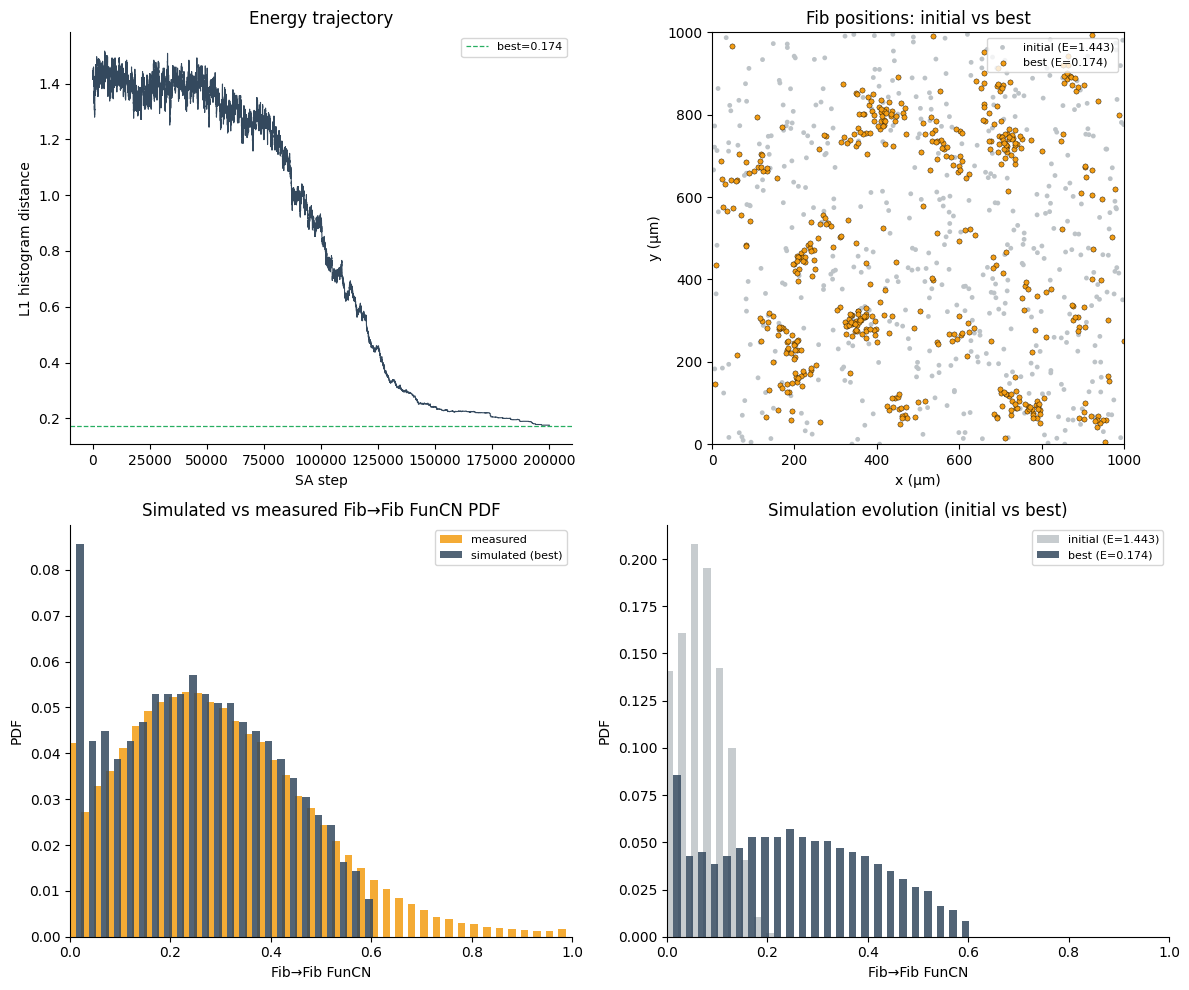

In [19]:
best_pos = res["positions"]
Kf       = pairwise_kernel(best_pos)
funcn_f  = funcn_per_cell(Kf.sum(axis=1))
sim_pdf_final = histogram_pdf(funcn_f)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.plot(res["energies"], color="#34495e", linewidth=0.8)
ax.axhline(res["best_energy"], color="#27ae60", linestyle="--", linewidth=0.9, label=f"best={res['best_energy']:.3f}")
ax.set_xlabel("SA step"); ax.set_ylabel("L1 histogram distance"); ax.set_title("Energy trajectory")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax = axes[0, 1]
ax.scatter(positions_init[:, 0], positions_init[:, 1], s=12, color="#bdc3c7",
           edgecolor="none", label=f"initial (E={E_init:.3f})")
ax.scatter(best_pos[:, 0], best_pos[:, 1], s=14, color="#f39c12",
           edgecolor="black", linewidth=0.3, label=f"best (E={res['best_energy']:.3f})")
ax.set_xlim(0, GRID_UM); ax.set_ylim(0, GRID_UM); ax.set_aspect("equal")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title("Fib positions: initial vs best")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1, 0]
w = 1.0 / N_BINS_FUNCN
ax.bar(bin_centers - w * 0.3, target_pdf,    width=w * 0.6, color="#f39c12", label="measured", alpha=0.85)
ax.bar(bin_centers + w * 0.3, sim_pdf_final, width=w * 0.6, color="#34495e", label="simulated (best)", alpha=0.85)
ax.set_xlim(0, 1)
ax.set_xlabel("Fib→Fib FunCN"); ax.set_ylabel("PDF")
ax.set_title("Simulated vs measured Fib→Fib FunCN PDF")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax = axes[1, 1]
ax.bar(bin_centers - w * 0.3, sim_pdf_init,  width=w * 0.6, color="#bdc3c7", label=f"initial (E={E_init:.3f})", alpha=0.85)
ax.bar(bin_centers + w * 0.3, sim_pdf_final, width=w * 0.6, color="#34495e", label=f"best (E={res['best_energy']:.3f})", alpha=0.85)
ax.set_xlim(0, 1)
ax.set_xlabel("Fib→Fib FunCN"); ax.set_ylabel("PDF")
ax.set_title("Simulation evolution (initial vs best)")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
print(f"Initial sim mean : {funcn_init.mean():.4f}    initial L1 : {E_init:.4f}")
print(f"Best sim mean    : {funcn_f.mean():.4f}    best L1    : {res['best_energy']:.4f}")
print(f"Measured mean    : {(target_pdf * bin_centers).sum():.4f}")

Initial sim mean : 0.0763    initial L1 : 1.4430
Best sim mean    : 0.2480    best L1    : 0.1743
Measured mean    : 0.3035
